# Introduction and Problem Statement:

Customer Churn means when people stop using a firm/company's services or products, so in competitive companies retaianing existing customers is very imortant and cost effective as compared to getting a new customer.
so, in this project building a model that predicts whether a customer is likely to exit the bank or not.

# Dataset Understanding and Description

The dataset is a customer dataset linked to Bank Churn Prediction and over a 10000 customer records, each representing a customer along with 14 other features having other details. The target variable is Exited which indicates whether a customer has churned.
Feature Breakdown
Customer Demographics: Geography (e.g., France, Spain, Germany), Gender, and Age.

Financial Metrics: CreditScore, Balance, and EstimatedSalary.

Account Behavior: Tenure (years with the bank), NumOfProducts (number of bank products used), HasCrCard (has a credit card: 1/0), and IsActiveMember (active status: 1/0).

Target Variable: Exited (1 if the customer churned, 0 if they stayed).

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


# Data Loading and Analysis

In [40]:
df = pd.read_csv('Churn_Modelling.csv')

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [41]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [43]:
# Droping irrelevant columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

df.isnull().sum() #looking for missing values

print(df['Exited'].value_counts(normalize=True)) # Analyzing churn balance

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


# Visualization

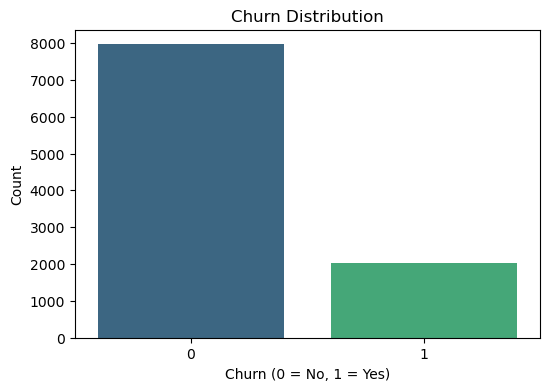

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


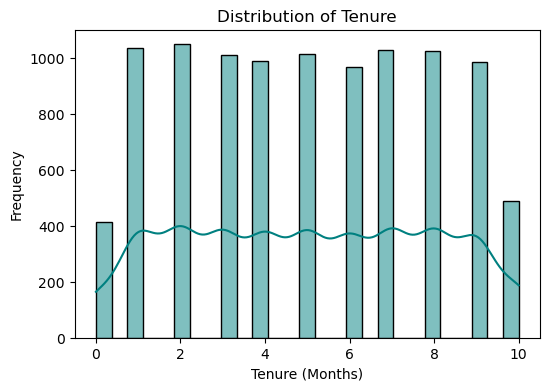

In [45]:
#plotting monthly charges distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Tenure'], kde=True, color='teal')
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()


# Encoding Categorical Figures

In [46]:
# Binary encoding for Gender
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# One-Hot Encoding for Geography
geography_encoded = pd.get_dummies(df['Geography'], prefix='Geo', dtype=int)
df = pd.concat([df, geography_encoded], axis=1)
df = df.drop(columns=['Geography'])


# Training Model (RandomForest)

In [47]:

X = df.drop(columns=['Exited'])
y = df['Exited']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling numerical features such that CreditScore, Age, Balance etc
scaler = StandardScaler()
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Training the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Analyzing Feature Importance

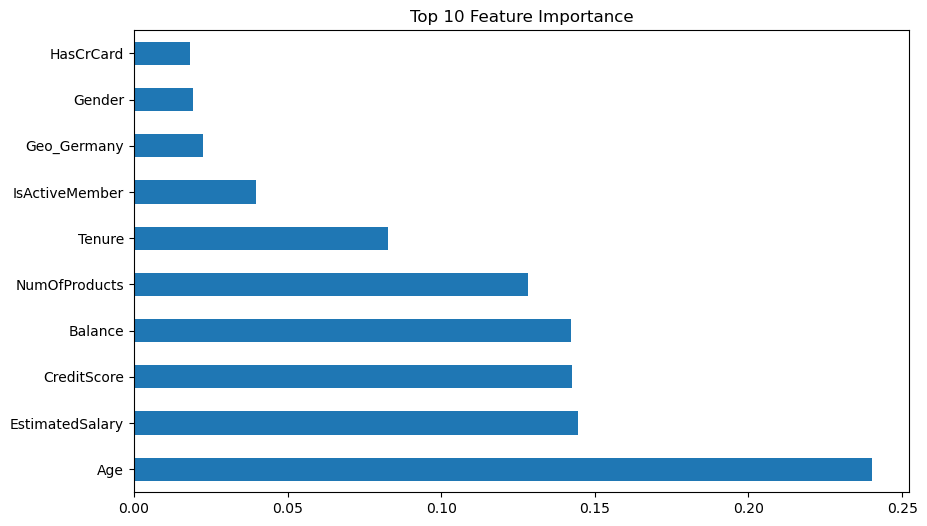

In [48]:
# Plotting feature importance

importances = pd.Series(model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.show()



# Conclusion

Analyzing the classification model and feature importance scores reveals several critical drivers behind customer churn:

Age is a Critical Factor: Older customers show a significantly higher tendency to churn compared to younger demographics. This suggests the bank's retention strategies or product offerings might not be aligning well with older age groups.

Product Overloading is Risky: Customers possessing a high number of bank products exhibit a massive spike in churn rates, potentially indicating poor user experience or accidental cross-selling friction.

Geography Matters: Customers based in Germany churn at a noticeably higher rate than those in France or Spain, pointing toward a regional competitor or localized service issues.Activity Level Saves Accounts: As expected, active members are vastly more loyal. 
Boosting general engagement via app usage or localized promotions is an effective way to mitigate risk.